<a href="https://colab.research.google.com/github/Nikhil0264/Collab_special/blob/main/dog_vs_ccat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
mkdir -p ~/.kaggle && echo KGAT_c19daffe35affe3975db000f028c2d6e > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

KGAT_c19daffe35affe3975db000f028c2d6e
export KAGGLE_API_TOKEN=KGAT_c19daffe35affe3975db000f028c2d6e

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("princelv84/dogsvscats")

print("Path to dataset files:", path)

100%|██████████| 545M/545M [00:07<00:00, 76.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1


In [ ]:
import os

print("Dataset path:", path)
print("\nFiles/folders:")
print(os.listdir(path))

Dataset path: /root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1

Files/folders:
['test', 'train']


In [ ]:
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")

/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1 -> 0 files
/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/test -> 0 files
/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/test/cats -> 2500 files
/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/test/dogs -> 2500 files
/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/train -> 0 files
/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/train/cats -> 10000 files
/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/train/dogs -> 10000 files


In [ ]:
train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

print("Train:", train_dir)
print("Test :", test_dir)

Train: /root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/train
Test : /root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/test


In [ ]:
import tensorflow as tf

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

from tensorflow.keras import layers,models
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array
from keras.utils import plot_model
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,auc
import seaborn as sns

In [ ]:
cat_dir = "/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/train/cats"
dog_dir = "/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/train/dogs"

In [ ]:
len(os.listdir(cat_dir)),len(os.listdir(dog_dir))

(10000, 10000)

array([[[101, 120, 155],
        [102, 121, 156],
        [102, 121, 156],
        ...,
        [117, 136, 174],
        [114, 133, 171],
        [110, 129, 167]],

       [[102, 121, 156],
        [103, 122, 157],
        [104, 123, 158],
        ...,
        [119, 138, 176],
        [116, 135, 173],
        [112, 131, 169]],

       [[105, 124, 159],
        [106, 125, 160],
        [106, 125, 160],
        ...,
        [121, 140, 178],
        [118, 137, 175],
        [114, 133, 171]],

       ...,

       [[ 53,  72,  99],
        [ 52,  71,  98],
        [ 51,  70,  97],
        ...,
        [ 32,  41,  61],
        [ 34,  45,  65],
        [ 38,  49,  71]],

       [[ 53,  72,  99],
        [ 52,  71,  98],
        [ 51,  70,  97],
        ...,
        [ 30,  37,  56],
        [ 31,  40,  60],
        [ 35,  43,  66]],

       [[ 53,  72,  99],
        [ 53,  72,  99],
        [ 51,  70,  97],
        ...,
        [ 25,  31,  50],
        [ 28,  35,  54],
        [ 32,  39,  59]]], dtype=uint8)
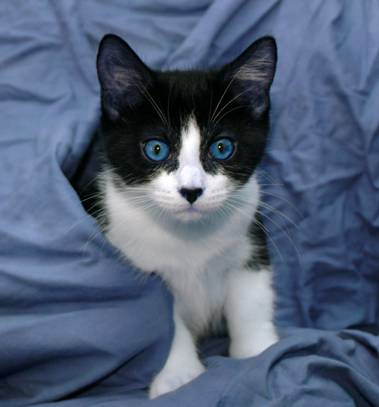

In [ ]:
cat_image = "/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/train/cats/cat.1002.jpg"
import cv2
img = cv2.imread(cat_image)
img

In [ ]:
base_dir='/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/train'
train_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',
    subset='training'
)

Found 16000 images belonging to 2 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 4000 images belonging to 2 classes.


In [ ]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

In [ ]:
model = models.Sequential([
    #layer 1
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

     #layer 2
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

     #layer 3
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

     #layer 4
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(512,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_generator,epochs=10,validation_data=validation_generator)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.6069 - loss: 0.6553 - val_accuracy: 0.6708 - val_loss: 0.5965
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 39s 48ms/step - accuracy: 0.7226 - loss: 0.5413 - val_accuracy: 0.7617 - val_loss: 0.4878
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.7960 - loss: 0.4345 - val_accuracy: 0.8125 - val_loss: 0.4096
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.8499 - loss: 0.3468 - val_accuracy: 0.8493 - val_loss: 0.3496
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.8775 - loss: 0.2838 - val_accuracy: 0.8652 - val_loss: 0.3142
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9074 - loss: 0.2234 - val_accuracy: 0.8763 - val_loss: 0.3122
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.9324 - loss: 0.1679 - val_accuracy: 0.8760 - val_loss: 0.3432
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.9509 - loss: 0.1267 - 

In [ ]:

test_datagen = ImageDataGenerator(rescale=1./255)
test_dir = "/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/test"

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary',
    shuffle=False
)

test_loss,test_accuracy = model.evaluate(test_generator,steps=len(test_generator))

print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

Found 5000 images belonging to 2 classes.
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8746 - loss: 0.4330
Test Loss: 0.4330071210861206
Test Accuracy: 0.8745999932289124


In [ ]:
probabilities = model.predict(test_generator)

250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step


In [ ]:
probabilities

array([[4.85633905e-07],
       [1.03016734e-01],
       [2.28983874e-04],
       ...,
       [9.99054849e-01],
       [1.83432907e-01],
       [9.99355018e-01]], dtype=float32)

In [ ]:
predicted_classes = (probabilities > 0.5).astype(int).squeeze()

In [ ]:
predicted_classes

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
test_generator.class_indices

{'cats': 0, 'dogs': 1}

In [ ]:
class_labels = list(test_generator.class_indices.keys())
predicted_labels = [class_labels[i] for i in predicted_classes]

In [ ]:
true_classes = test_generator.classes

CM = confusion_matrix(true_classes,predicted_classes)
CM

array([[2133,  367],
       [ 260, 2240]])

In [ ]:
test_image = "/root/.cache/kagglehub/datasets/princelv84/dogsvscats/versions/1/test/cats/cat.1000.jpg"

img = load_img(test_image,target_size=(150,150))
img_array = img_to_array(img)
img_array = img_array/255.0
img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)
prediction